In [1]:
# Option A: Simple install
#!pip install requests pandas matplotlib  ta-lib

📈 BACKTEST: 600519.SS
Initial Capital ($)    : 10000
Final Capital ($)      : 10769.9
Total Return (%)       : 7.7
Closed Trades          : 3
Win Rate (%)           : 33.33
Net Profit ($)         : 606.77

📋 TRADE LOG:
--------------------------------------------------
2025-02-13 | BUY  | Price:  1380.11 | Shares:    7 | Fee:   9.66
2025-02-26 | SELL | Price:  1375.35 | Shares:    7 | Fee:   9.63
2025-03-04 | BUY  | Price:  1384.86 | Shares:    7 | Fee:   9.69
2025-03-26 | SELL | Price:  1484.61 | Shares:    7 | Fee:  10.39
2025-04-14 | BUY  | Price:   1462.0 | Shares:    7 | Fee:  10.23
2025-04-24 | SELL | Price:  1462.24 | Shares:    7 | Fee:  10.24
2025-05-08 | BUY  | Price:  1486.68 | Shares:    7 | Fee:  10.41


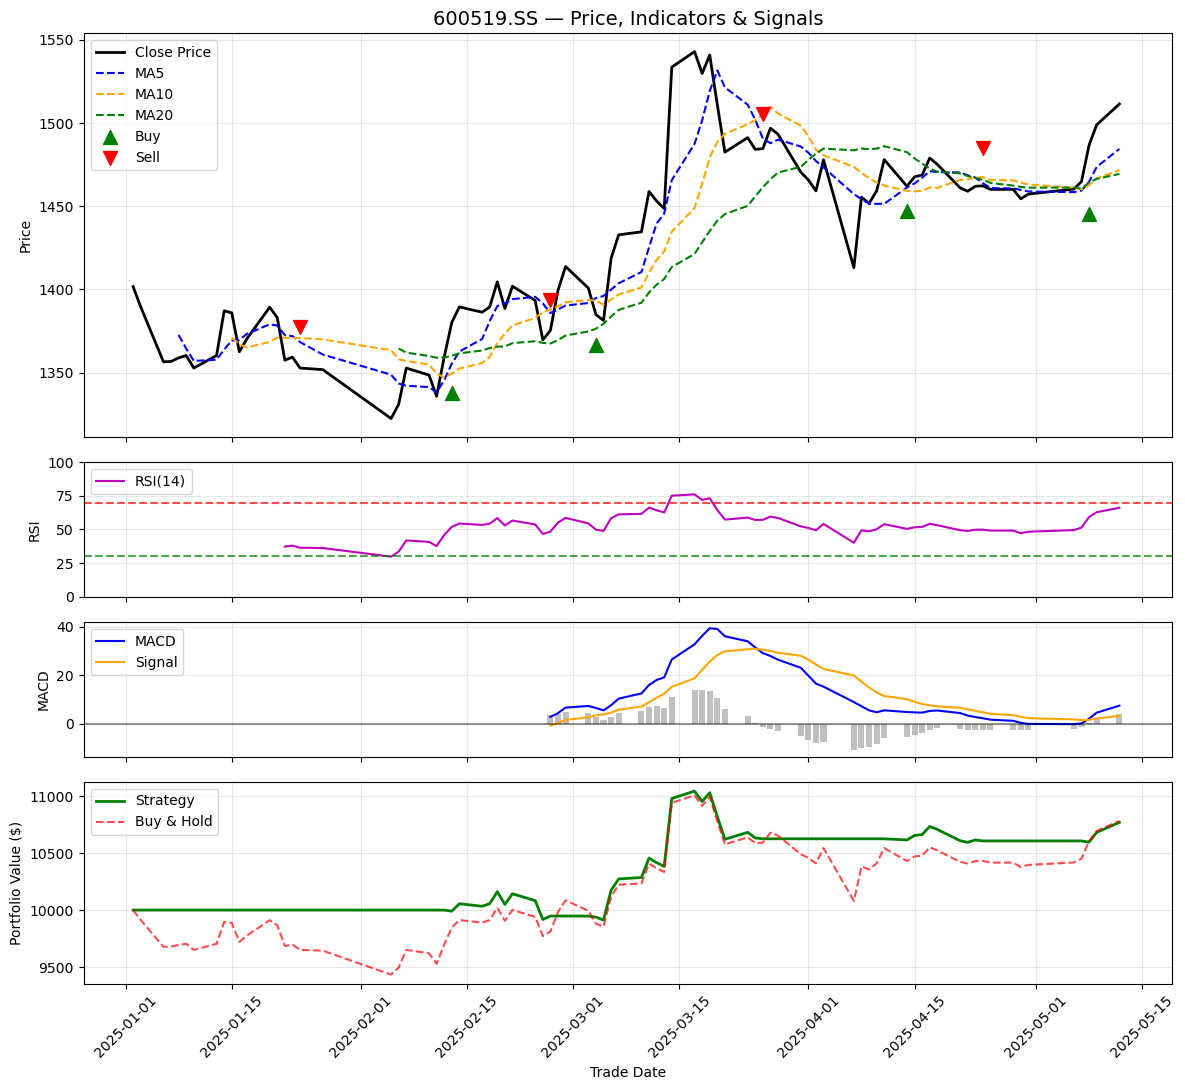


✅ Saved to: data/600519.SS_*.csv


({'Initial Capital ($)': 10000,
  'Final Capital ($)': 10769.9,
  'Total Return (%)': 7.7,
  'Closed Trades': 3,
  'Win Rate (%)': 33.33,
  'Net Profit ($)': 606.77},
 Price trade_date         open         high          low        close      vol  \
 0     2025-01-02  1435.628175  1436.089752  1394.179592  1401.715698  5002870   
 1     2025-01-03  1407.838864  1408.300441  1381.942927  1389.469604  3262836   
 2     2025-01-06  1368.745318  1377.845199  1349.716696  1356.499146  4425512   
 3     2025-01-07  1360.888957  1367.699695  1355.557130  1356.687500  2422118   
 4     2025-01-08  1356.499093  1367.633639  1343.932668  1358.854126  3525821   
 ..           ...          ...          ...          ...          ...      ...   
 78    2025-05-06  1468.598600  1468.598600  1454.779225  1460.308838  1830026   
 79    2025-05-07  1478.960765  1478.960765  1460.308857  1464.830566  2746221   
 80    2025-05-08  1462.946644  1500.419960  1459.960420  1486.675903  3348106   
 81    2025-0

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import talib

# -----------------------------------------------------------------------------
# 🎯 CONFIGURATION — CHANGE THESE VALUES ONLY
# -----------------------------------------------------------------------------
# Example tickers:
#   Ping An Bank     = 000001.SZ
#   Guizhou Maotai   = 600519.SS
#   Kweichow Moutai  = same as above
#   Midea Group      = 000333.SZ
#   BYD             = 002594.SZ
TICKER = "600519.SS"       # Guizhou Maotai
START_DATE = "2025-01-01"
END_DATE = "2025-05-13"
INITIAL_CAPITAL = 10000
TRANSACTION_FEE_RATE = 0.001  # 0.1% per trade

os.makedirs("data", exist_ok=True)

# -----------------------------------------------------------------------------
# 🚀 MAIN FUNCTION — RUNS ALL STEPS AUTOMATICALLY
# -----------------------------------------------------------------------------


def run_strategy(ticker, start, end, capital, fee_rate):
    # --------------------------
    # 1. Fetch & clean data
    # --------------------------
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        print(f"❌ No data found for {ticker}. Check ticker format!")
        return None, None, None

    df = df.droplevel("Ticker", axis=1).reset_index()
    df = df.rename(columns={
        "Date": "trade_date", "Open": "open", "High": "high",
        "Low": "low", "Close": "close", "Volume": "vol"
    })
    df = df[["trade_date", "open", "high", "low", "close", "vol"]]
    df["trade_date"] = pd.to_datetime(df["trade_date"])
    df = df.sort_values("trade_date").reset_index(drop=True)

    # --------------------------
    # 2. Calculate indicators
    # --------------------------
    close = df["close"].values
    df["MA5"] = talib.SMA(close, timeperiod=5)
    df["MA10"] = talib.SMA(close, timeperiod=10)
    df["MA20"] = talib.SMA(close, timeperiod=20)
    df["RSI"] = talib.RSI(close, timeperiod=14)
    macd, macd_signal, macd_hist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = macd, macd_signal, macd_hist

    # --------------------------
    # 3. Generate Buy/Sell signals
    # --------------------------
    df["Buy_Signal"] = 0.0
    df["Sell_Signal"] = 0.0
    for i in range(1, len(df)):
        if (df["MA5"].iloc[i] > df["MA10"].iloc[i] and
            df["MA5"].iloc[i - 1] <= df["MA10"].iloc[i - 1] and
                df["RSI"].iloc[i] < 70):
            df.loc[i, "Buy_Signal"] = df["low"].iloc[i] * 0.99

        if (df["MA5"].iloc[i] < df["MA10"].iloc[i] and
            df["MA5"].iloc[i - 1] >= df["MA10"].iloc[i - 1] and
                df["RSI"].iloc[i] > 30):
            df.loc[i, "Sell_Signal"] = df["high"].iloc[i] * 1.01

    # --------------------------
    # 4. Backtest with fees
    # --------------------------
    def backtest(data, initial_cap, fee):
        cap = float(initial_cap)
        shares = 0
        position = 0
        trades = []
        bt_df = data.copy()
        bt_df["Position"] = 0
        bt_df["Portfolio_Value"] = 0.0

        for i in range(len(bt_df)):
            price = float(bt_df["close"].iloc[i])
            date = bt_df["trade_date"].iloc[i]

            if bt_df["Buy_Signal"].iloc[i] > 0 and position == 0:
                shares = int(cap // price)
                if shares == 0:
                    continue
                cost = shares * price
                trading_fee = cost * fee
                cap -= (cost + trading_fee)
                position = 1
                trades.append({
                    "date": date, "type": "BUY", "price": round(price, 2),
                    "shares": shares, "fee": round(trading_fee, 2)
                })

            elif bt_df["Sell_Signal"].iloc[i] > 0 and position == 1:
                proceeds = shares * price
                trading_fee = proceeds * fee
                cap += (proceeds - trading_fee)
                trades.append({
                    "date": date, "type": "SELL", "price": round(price, 2),
                    "shares": shares, "fee": round(trading_fee, 2)
                })
                shares = 0
                position = 0

            bt_df.loc[i, "Position"] = position
            bt_df.loc[i, "Portfolio_Value"] = round(cap + shares * price, 2)

        if position == 1:
            cap += shares * float(bt_df["close"].iloc[-1])

        final_val = round(cap, 2)
        total_return = round((final_val - initial_cap) / initial_cap * 100, 2)
        closed_trades = [t for t in trades if t["type"] == "SELL"]
        win = 0
        net_profit = 0.0

        for j in range(0, len(trades) - 1, 2):
            if j + 1 >= len(trades):
                break
            pnl = (trades[j + 1]["price"] - trades[j]["price"]) * trades[j]["shares"] - trades[j]["fee"] - trades[j + 1]["fee"]
            net_profit += pnl
            if pnl > 0:
                win += 1

        win_rate = round(win / len(closed_trades) * 100, 2) if closed_trades else 0.0

        summary = {
            "Initial Capital ($)": initial_cap,
            "Final Capital ($)": final_val,
            "Total Return (%)": total_return,
            "Closed Trades": len(closed_trades),
            "Win Rate (%)": win_rate,
            "Net Profit ($)": round(net_profit, 2)
        }
        return summary, bt_df, trades

    summary, bt_df, trades = backtest(df, capital, fee_rate)

    # --------------------------
    # 5. Print results
    # --------------------------
    print("=" * 50)
    print(f"📈 BACKTEST: {ticker}")
    print("=" * 50)
    for k, v in summary.items():
        print(f"{k:<22} : {v}")

    if trades:
        print("\n📋 TRADE LOG:")
        print("-" * 50)
        for t in trades:
            print(f"{t['date'].strftime('%Y-%m-%d')} | {t['type']:4} | Price: {t['price']:>8} | Shares: {t['shares']:>4} | Fee: {t['fee']:>6.2f}")

    # --------------------------
    # 6. Plot everything
    # --------------------------
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        nrows=4, figsize=(12, 11), sharex=True,
        gridspec_kw={"height_ratios": [3, 1, 1, 1.5]}
    )

    # Price + MAs + Signals
    ax1.plot(df["trade_date"], df["close"], "k", lw=2, label="Close Price")
    ax1.plot(df["trade_date"], df["MA5"], "b--", label="MA5")
    ax1.plot(df["trade_date"], df["MA10"], "orange", linestyle="--", label="MA10")
    ax1.plot(df["trade_date"], df["MA20"], "g--", label="MA20")
    ax1.scatter(df[df["Buy_Signal"] > 0]["trade_date"], df[df["Buy_Signal"] > 0]["Buy_Signal"], marker="^", c="green", s=100, zorder=5, label="Buy")
    ax1.scatter(df[df["Sell_Signal"] > 0]["trade_date"], df[df["Sell_Signal"] > 0]["Sell_Signal"], marker="v", c="red", s=100, zorder=5, label="Sell")
    ax1.set_title(f"{ticker} — Price, Indicators & Signals", fontsize=14)
    ax1.set_ylabel("Price")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)

    # RSI
    ax2.plot(df["trade_date"], df["RSI"], "m", label="RSI(14)")
    ax2.axhline(70, c="r", ls="--", alpha=0.7)
    ax2.axhline(30, c="g", ls="--", alpha=0.7)
    ax2.set_ylabel("RSI")
    ax2.legend(loc="upper left")
    ax2.grid(alpha=0.3)
    ax2.set_ylim(0, 100)

    # MACD
    ax3.plot(df["trade_date"], df["MACD"], "b", label="MACD")
    ax3.plot(df["trade_date"], df["MACD_Signal"], "orange", label="Signal")
    ax3.bar(df["trade_date"], df["MACD_Hist"], color="gray", alpha=0.5)
    ax3.axhline(0, c="black", ls="-", alpha=0.4)
    ax3.set_ylabel("MACD")
    ax3.legend(loc="upper left")
    ax3.grid(alpha=0.3)

    # Equity Curve
    bt_df["BuyHold_Value"] = capital * (bt_df["close"] / bt_df["close"].iloc[0])
    ax4.plot(bt_df["trade_date"], bt_df["Portfolio_Value"], "g", lw=2, label="Strategy")
    ax4.plot(bt_df["trade_date"], bt_df["BuyHold_Value"], "r--", alpha=0.7, label="Buy & Hold")
    ax4.set_xlabel("Trade Date")
    ax4.set_ylabel("Portfolio Value ($)")
    ax4.legend(loc="upper left")
    ax4.grid(alpha=0.3)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Save files
    df.to_csv(f"data/{ticker}_indicators.csv", index=False)
    bt_df.to_csv(f"data/{ticker}_backtest.csv", index=False)
    print(f"\n✅ Saved to: data/{ticker}_*.csv")

    return summary, bt_df, trades


# -----------------------------------------------------------------------------
# ▶️ RUN IT!
# -----------------------------------------------------------------------------
run_strategy(
    ticker=TICKER,
    start=START_DATE,
    end=END_DATE,
    capital=INITIAL_CAPITAL,
    fee_rate=TRANSACTION_FEE_RATE
)